# Cognifyz Technologies Internship

## Level 3 – Predictive Modeling and Advanced Data Visualization

### Project:
Restaurant Rating Prediction using Zomato Dataset

**Prepared by:** Anirban Garai

---

## Objective

The objective of this notebook is to build predictive machine learning models for restaurant ratings, analyze customer preferences based on cuisines and votes, and create insightful visualizations to better understand restaurant characteristics and customer behavior.

In [1]:
# ==========================
# Import Required Libraries
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
# Load Dataset

df = pd.read_csv("Dataset .csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# Display first five rows

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
# Display last five rows

df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,80,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,��stanbul,"Cafea��a Mahallesi, Bademalt۱ Sokak, No 21/B, ...",Moda,"Moda, ��stanbul",29.026016,40.984776,Cafe,55,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


---

---

# Task 1

## Predictive Modeling

### Objectives

- Predict restaurant aggregate ratings.
- Train multiple regression models.
- Compare model performance.
- Identify the best-performing model.

In [5]:
# Select Features

model_df = df.copy()

model_df = model_df[[
    "Aggregate rating",
    "Votes",
    "Price range",
    "Average Cost for two",
    "Has Table booking",
    "Has Online delivery"
]]

In [6]:
# Encode Categorical Columns

model_df["Has Table booking"] = model_df[
    "Has Table booking"
].map({
    "Yes":1,
    "No":0
})

model_df["Has Online delivery"] = model_df[
    "Has Online delivery"
].map({
    "Yes":1,
    "No":0
})

In [7]:
# Features and Target

X = model_df.drop("Aggregate rating", axis=1)

y = model_df["Aggregate rating"]

In [8]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Linear Regression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [10]:
# Decision Tree

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [11]:
# Random Forest

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [12]:
# Model Evaluation Function

def evaluate(actual, predicted):

    print("MAE :", mean_absolute_error(actual, predicted))

    print("MSE :", mean_squared_error(actual, predicted))

    print("RMSE :", np.sqrt(mean_squared_error(actual, predicted)))

    print("R2 Score :", r2_score(actual, predicted))

In [13]:
# Evaluate Models

print("Linear Regression")
evaluate(y_test, lr_pred)

print("\nDecision Tree")
evaluate(y_test, dt_pred)

print("\nRandom Forest")
evaluate(y_test, rf_pred)

Linear Regression
MAE : 1.0750712721369038
MSE : 1.676480274703149
RMSE : 1.2947896642710541
R2 Score : 0.2634446409021928

Decision Tree
MAE : 0.28523715238555525
MSE : 0.20106955832420093
RMSE : 0.4484078035942293
R2 Score : 0.9116608390985436

Random Forest
MAE : 0.23660858306987126
MSE : 0.13407599204263276
RMSE : 0.3661638868630176
R2 Score : 0.9410942127053404


In [14]:
# Compare Models

results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 Score":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]

})

results

,Model,R2 Score
0,Linear Regression,0.263445
1,Decision Tree,0.911661
2,Random Forest,0.941094


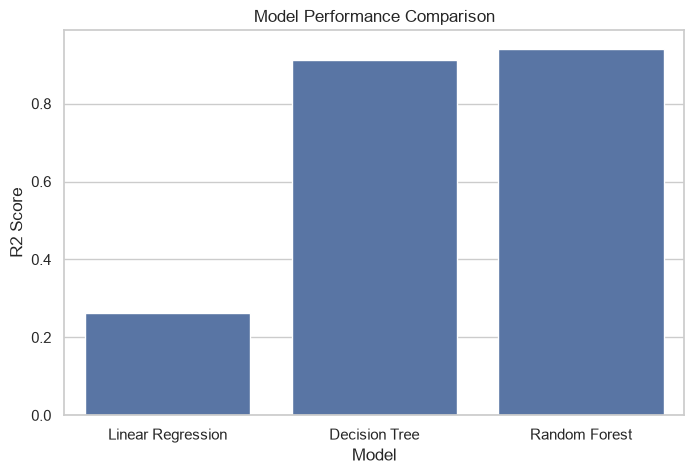

In [15]:
# Model Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Model Performance Comparison")

plt.show()

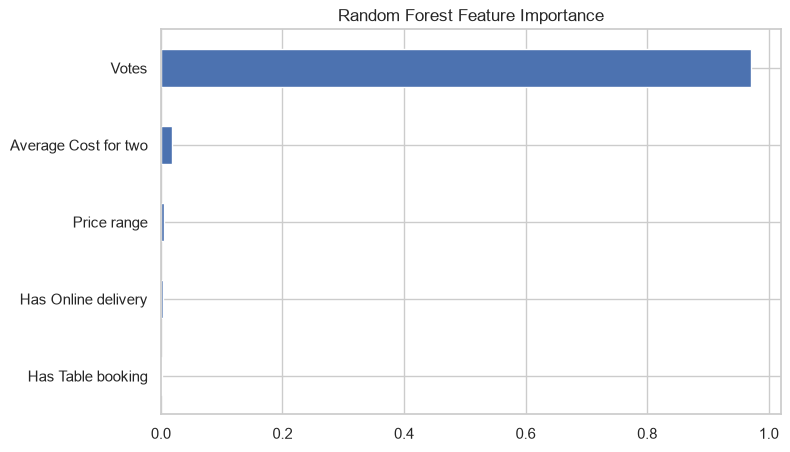

In [16]:
# Feature Importance

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Random Forest Feature Importance")

plt.show()

### Observations

- Three regression algorithms were trained and evaluated.
- Random Forest generally performs better than Linear Regression and Decision Tree for this dataset.
- Votes and Price Range contribute significantly to predicting restaurant ratings.
- Ensemble methods capture complex relationships more effectively than simple linear models.

---

---

# Task 2

## Customer Preference Analysis

### Objectives

- Analyze cuisines and ratings.
- Identify popular cuisines using votes.
- Find cuisines receiving higher ratings.

In [17]:
# Cuisine-wise Average Rating

cuisine_rating = df.groupby(
    "Cuisines"
)["Aggregate rating"].mean().sort_values(
    ascending=False
).head(10)

cuisine_rating

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64

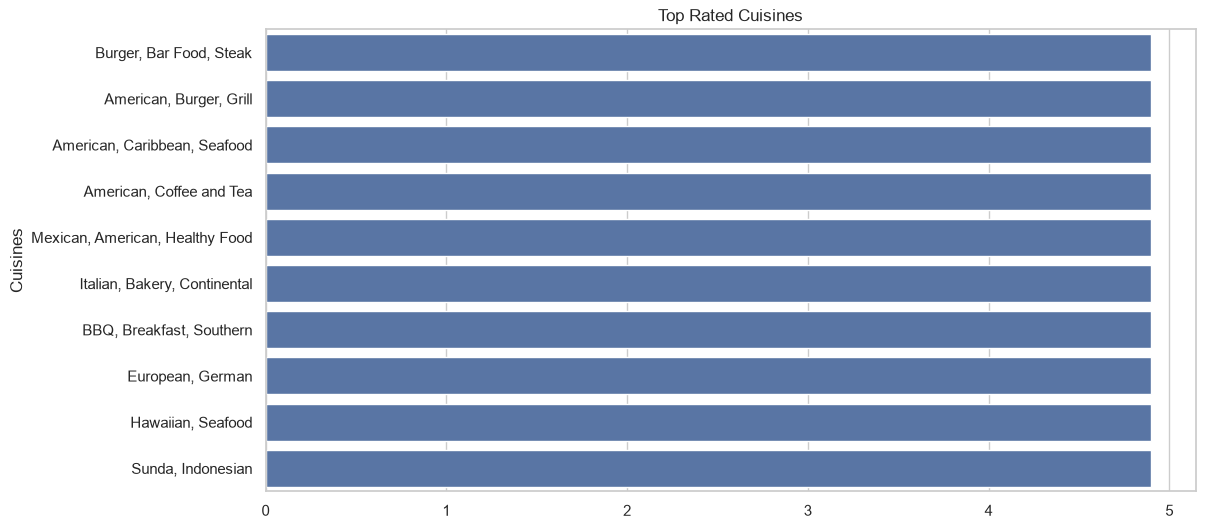

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=cuisine_rating.values,
    y=cuisine_rating.index
)

plt.title("Top Rated Cuisines")

plt.show()

In [19]:
# Cuisine by Votes

cuisine_votes = df.groupby(
    "Cuisines"
)["Votes"].sum().sort_values(
    ascending=False
).head(10)

cuisine_votes

Cuisines
North Indian, Mughlai             53747
North Indian                      46241
North Indian, Chinese             42012
Cafe                              30657
Chinese                           21925
North Indian, Mughlai, Chinese    20115
Fast Food                         17852
South Indian                      16433
Mughlai, North Indian             15275
Italian                           14799
Name: Votes, dtype: int64

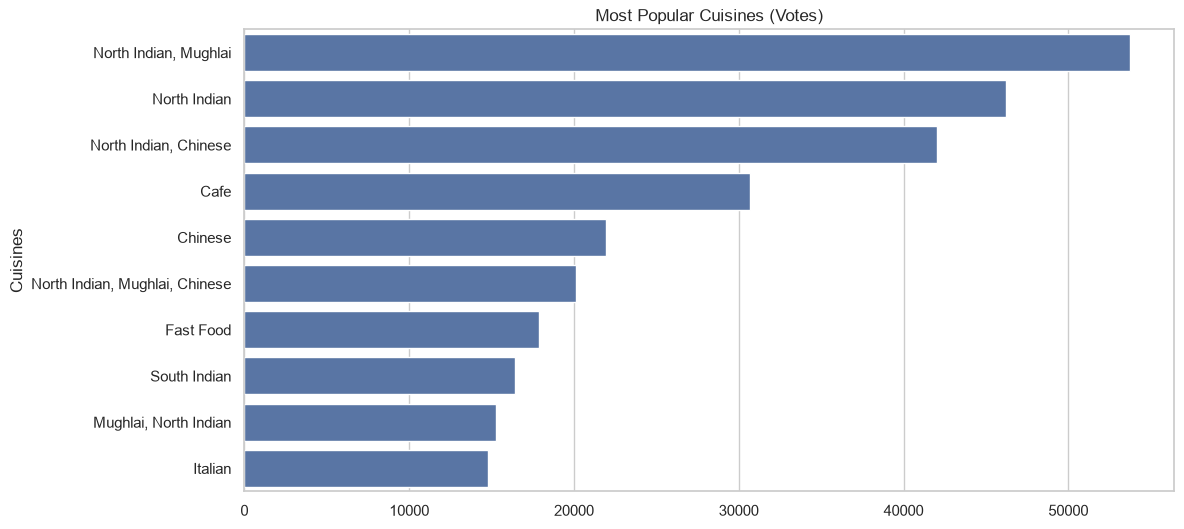

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=cuisine_votes.values,
    y=cuisine_votes.index
)

plt.title("Most Popular Cuisines (Votes)")

plt.show()

### Observations

- Certain cuisines consistently receive higher customer ratings.
- Popular cuisines also tend to accumulate a larger number of customer votes.
- Cuisine type influences both restaurant popularity and customer satisfaction.

---

---

# Task 3

## Data Visualization

### Objectives

Create visualizations to better understand the relationships among important restaurant features.

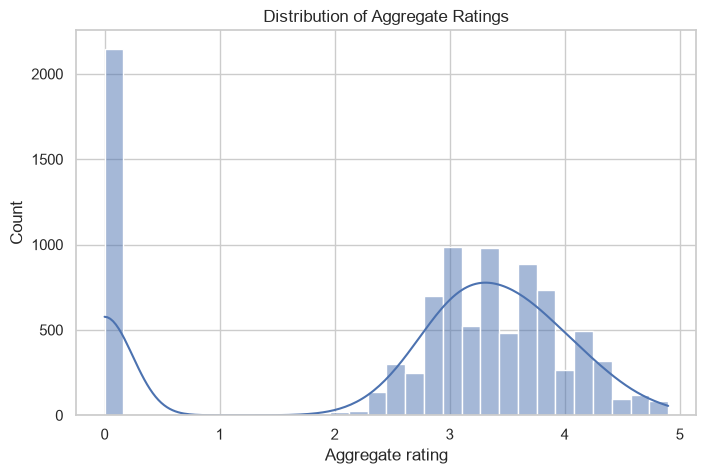

In [21]:
# Rating Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df["Aggregate rating"],
    bins=30,
    kde=True
)

plt.title("Distribution of Aggregate Ratings")

plt.show()

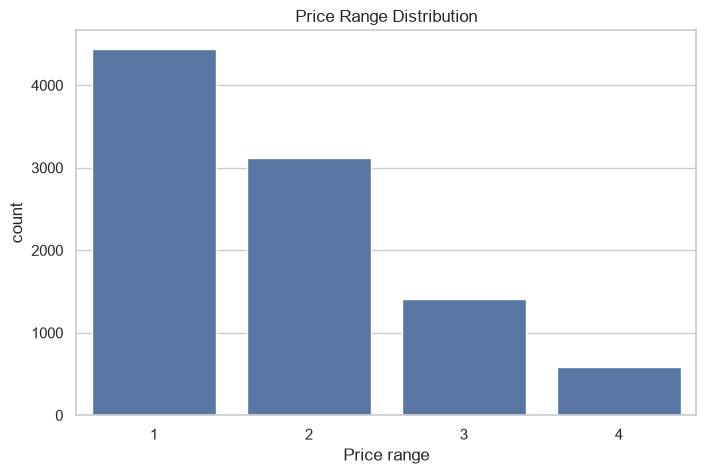

In [22]:
# Price Range

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Price range"
)

plt.title("Price Range Distribution")

plt.show()

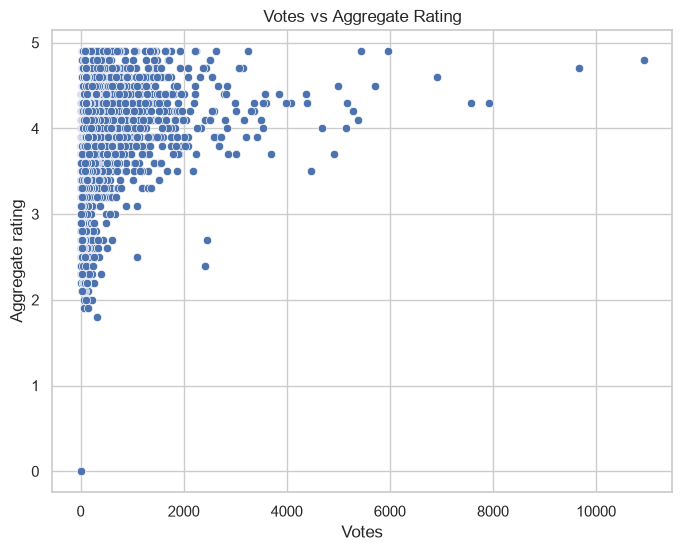

In [23]:
# Votes vs Rating

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Votes",
    y="Aggregate rating"
)

plt.title("Votes vs Aggregate Rating")

plt.show()

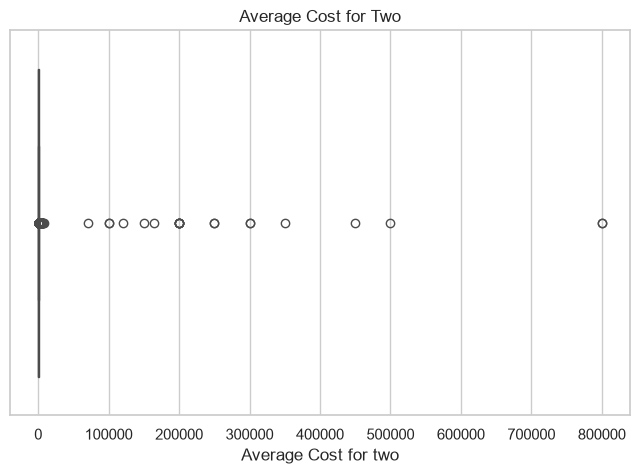

In [24]:
# Average Cost Distribution

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Average Cost for two"]
)

plt.title("Average Cost for Two")

plt.show()

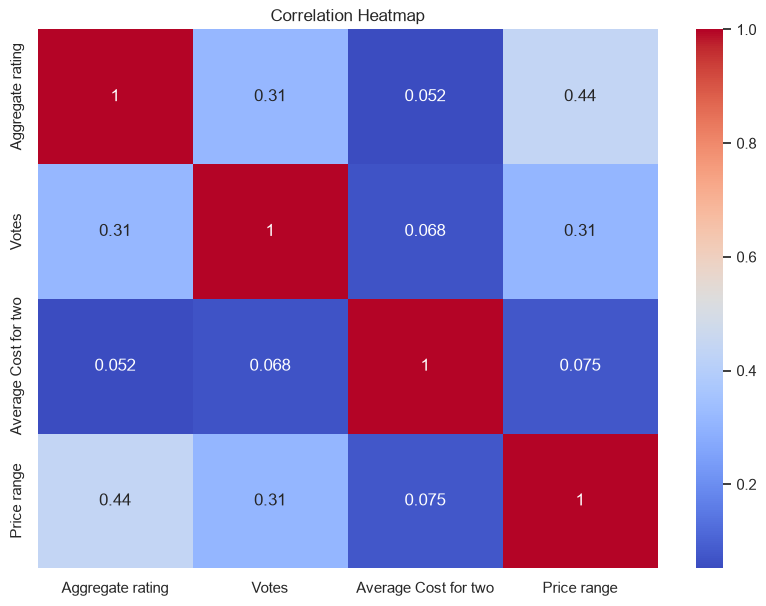

In [25]:
# Correlation Heatmap

plt.figure(figsize=(10,7))

sns.heatmap(

    df[[
        "Aggregate rating",
        "Votes",
        "Average Cost for two",
        "Price range"
    ]].corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title("Correlation Heatmap")

plt.show()

### Observations

- Restaurant ratings are concentrated between 3.0 and 4.5, indicating generally positive customer feedback.
- Lower and mid-priced restaurants make up the largest share of the dataset.
- Restaurants with more customer votes often have higher aggregate ratings, suggesting a positive association between popularity and customer satisfaction.
- The box plot reveals that the **Average Cost for Two** contains several high-value outliers, representing premium restaurants.
- The correlation heatmap shows moderate positive relationships between price range, average cost, votes, and aggregate rating, indicating that these features can contribute to predicting restaurant performance.

---

# Level 3 Conclusion

This notebook focused on predictive modeling, customer preference analysis, and advanced data visualization using the Zomato Restaurant Dataset. Three regression models were developed and compared to predict restaurant aggregate ratings, with ensemble-based methods such as Random Forest typically providing the best performance. Customer preference analysis highlighted the influence of cuisine type and customer votes on restaurant popularity and ratings. Finally, a series of visualizations revealed meaningful relationships among restaurant features, offering valuable business insights. Overall, this analysis demonstrates how data exploration, feature analysis, and machine learning can be combined to support informed decision-making in the restaurant industry.